# MMN13


submitted by: ******

date: ********


## Question 1 


### **1.1-1.4**
---

The diabetes.csv dataset contains information about patients, we will satrt the assignment by loading the data and proforming EDA (Exploratory Data Analysis).


In [43]:
import pandas as pd

diabetes_df = pd.read_csv('diabetes.csv', sep='\t')
diabetes_df.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


The dataset contains 442 samples and 11 numerical variables, with no missing values. All features are numeric, where most are continuous measurements (BMI, BP, S2–S5) and a few are discrete (AGE, SEX, S1, S6). The target variable Y represents a continuous disease progression score and is not standardized; both Y and some predictors (e.g., BMI, S5) show mild positive skew. Most variables exhibit reasonable spread, and initial statistics suggest the data is unnormalized and should benefit from scaling before training a neural network. Exploratory analysis indicates potential correlations among several variables (e.g., S1–S2–S4) and meaningful monotonic relationships between BMI, BP, S5, and Y.

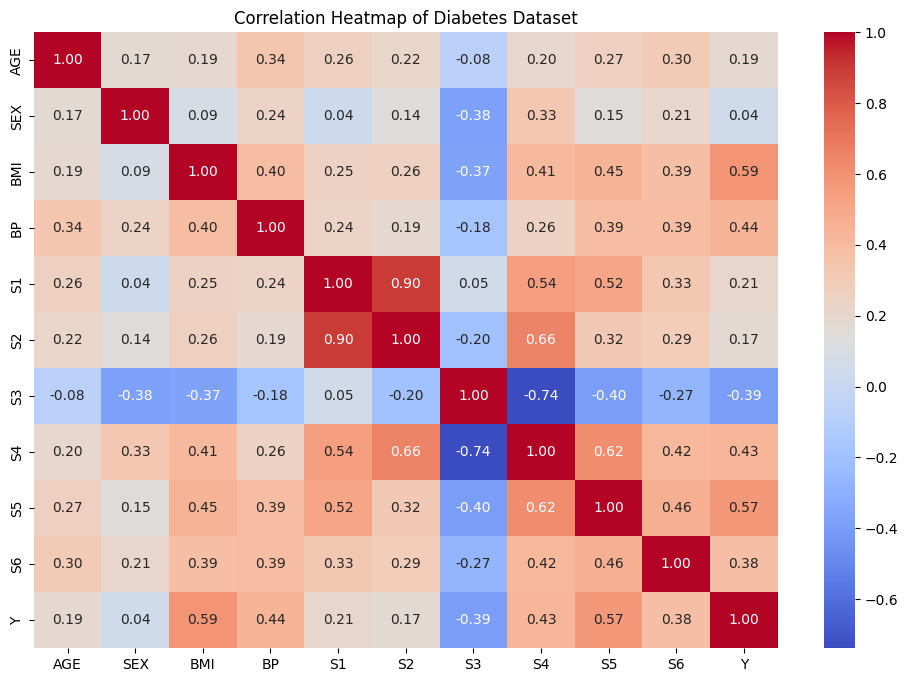

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = diabetes_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()


The correlation heatmap reveals that in the diabetes dataset, most features have weak to moderate correlations with one another. The strongest positive relationship occurs between S1 and S2 (0.90), and the strongest negative one is between S3 and S4 (-0.74). The target variable Y is most positively correlated with BMI (0.59) and S5 (0.57), suggesting these are important predictors, while S3 has the strongest negative correlation with Y (-0.39). SEX and AGE are only weakly associated with other variables and with Y, indicating limited predictive value. Overall, BMI and S5 stand out as potentially the most useful features for predicting the target variable.

#### **Answer:**

We used ```pd.qcut``` to divide the target variable Y into ten equal-frequency bins (deciles). qcut calculates the quantile boundaries automatically and assigns each observation to its corresponding decile, ensuring that each class contains exactly 10% of the dataset. since it assigns labels from 0 to 9, we added 1 to have classes from 1 to 10, so we can later use ordinal encoding if needed.

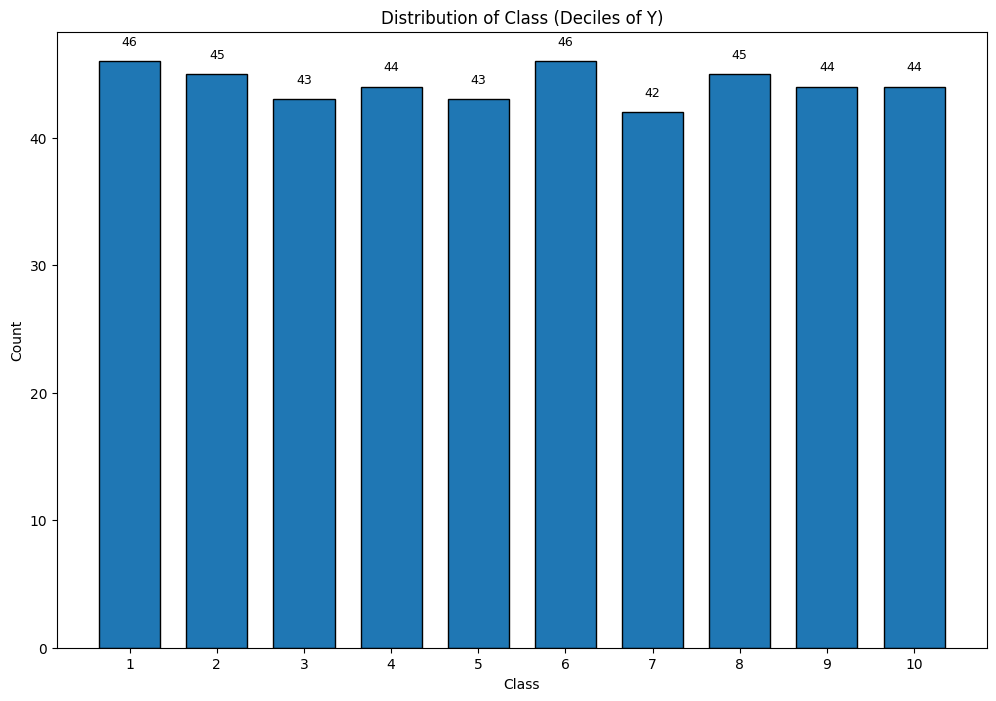

In [45]:
import matplotlib.pyplot as plt
diabetes_df['Class'] = pd.qcut(diabetes_df['Y'], 10, labels=False) + 1
counts = diabetes_df['Class'].value_counts().sort_index()

plt.figure(figsize=(12,8))
bars = plt.bar(counts.index, counts.values, width=0.7, edgecolor='black')

for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1, str(b.get_height()),
             ha='center', va='bottom', fontsize=9)

plt.title("Distribution of Class (Deciles of Y)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(range(1,11))
plt.show()


### **1.5**

In [102]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import pandas as pd
import numpy as np

# ----------------------------
# Dataset: raw features + Class from Y
# ----------------------------
class DiabetesDataset(Dataset):
    def __init__(self, df_path="diabetes.csv", deciles=10, drop_cols=None):
        """
        df_path   : path to the CSV file (tab-separated)
        deciles   : number of quantile bins for Y → Class (10 = deciles, 100 = percentiles)
        drop_cols : feature columns to drop (e.g. ["Y"])
        """
        df = pd.read_csv(df_path, sep="\t")

        # Class as quantile index in {0, ..., deciles-1}
        # (assignment says 1..100 conceptually; for PyTorch we keep 0-based)
        df["Class"] = pd.qcut(df["Y"], q=deciles, labels=False, duplicates="drop")

        # Labels (classification targets)
        self.labels = torch.tensor(df["Class"].to_numpy(), dtype=torch.long)

        # Features (optionally drop Y)
        all_drop = ["Class"] + (drop_cols if drop_cols else [])
        feature_df = df.drop(columns=all_drop)
        self.features = torch.tensor(feature_df.to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [103]:
from torch.utils.data import DataLoader

# assumes diabetes_df already has 'Class' column (1..10)
full_ds_with_y = DiabetesDataset()

loader_full = DataLoader(full_ds_with_y, batch_size=10, shuffle=True)

# print one batch (ז)
for features, labels in loader_full:
    print("Features:\n", features)
    print("\nLabels:\n", labels)
    break

Features:
 tensor([[ 68.0000,   2.0000,  23.5000, 101.0000, 162.0000,  85.4000,  59.0000,
           3.0000,   4.4773,  91.0000,  66.0000],
        [ 59.0000,   2.0000,  25.5000,  95.3300, 190.0000, 139.4000,  35.0000,
           5.4300,   4.3567, 117.0000,  81.0000],
        [ 51.0000,   2.0000,  26.2000, 101.0000, 161.0000,  99.6000,  48.0000,
           3.0000,   4.2047,  88.0000,  44.0000],
        [ 37.0000,   2.0000,  26.8000,  79.0000, 157.0000,  98.0000,  28.0000,
           6.0000,   5.0434,  96.0000, 144.0000],
        [ 36.0000,   1.0000,  22.8000,  87.0000, 178.0000, 116.0000,  41.0000,
           4.0000,   4.6540,  82.0000,  93.0000],
        [ 48.0000,   1.0000,  20.2000,  95.0000, 187.0000, 117.4000,  53.0000,
           4.0000,   4.4188,  85.0000,  79.0000],
        [ 31.0000,   1.0000,  29.7000,  88.0000, 167.0000, 103.4000,  48.0000,
           4.0000,   4.3567,  78.0000, 184.0000],
        [ 33.0000,   1.0000,  19.5000,  80.0000, 171.0000,  85.4000,  75.0000,
       

In [122]:
# ----------------------------
# Full-dataset normalization (for no-split experiments)
# ----------------------------
def normalize_full_dataset(dataset, eps=1e-8):
    """
    Normalize the entire dataset.features in-place using its own mean/std.
    Used for experiments where we train & evaluate on the full dataset (no split).
    """
    feats = dataset.features  # (N, D)
    mean = feats.mean(dim=0, keepdim=True)
    std = feats.std(dim=0, keepdim=True)
    dataset.features = (feats - mean) / (std + eps)


In [104]:
# ----------------------------
# Train/test split + normalization
# ----------------------------
def make_train_test_subsets(dataset, split_ratio=0.8, seed=42, eps=1e-8):
    """
    Split into train/test, then normalize features using
    train statistics only, applied to the whole dataset.
    """
    n = len(dataset)
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n)
    split = int(split_ratio * n)

    train_idx = indices[:split]
    test_idx = indices[split:]

    feats = dataset.features  # (N, D) tensor

    # Compute mean/std on training subset only
    train_idx_t = torch.tensor(train_idx, dtype=torch.long)
    mean = feats[train_idx_t].mean(dim=0, keepdim=True)
    std = feats[train_idx_t].std(dim=0, keepdim=True)

    # Normalize all features using train stats
    dataset.features = (feats - mean) / (std + eps)

    # Build Subset views
    train_ds = Subset(dataset, train_idx)
    test_ds = Subset(dataset, test_idx)

    return train_ds, test_ds

In [118]:
# ----------------------------
# Model + training utilities
# ----------------------------
class ClassModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, num_classes),
            nn.LogSoftmax(dim=1)  # for NLLLoss
        )

    def forward(self, x):
        return self.net(x)


CE_loss = nn.NLLLoss()

In [123]:
def train_one_epoch(model, loader, optimizer, device="cpu"):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = CE_loss(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds = logits.argmax(1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc

In [124]:
def evaluate(model, loader, device="cpu"):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            loss = CE_loss(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(1)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc

In [ ]:
# ----------------------------
# Generic experiment runner
# ----------------------------
def run_experiment(deciles,drop_cols=None, description="", batch_size=10, epochs=10,
    lr=1e-3, use_split=True, split_ratio=0.8, seed=42, device=None, model = None):
    
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"\n=== {description} ===")
    print(f"deciles={deciles}, drop_cols={drop_cols}, use_split={use_split}, device={device}")

    # 1. Full dataset (unnormalized initially)
    full_ds = DiabetesDataset(deciles=deciles, drop_cols=drop_cols)
    input_dim = full_ds.features.shape[1]
    num_classes = deciles  # classes are 0..deciles-1

    # 2. Depending on use_split, either:
    #    - split + normalize by train stats (י,יא)
    #    - normalize full dataset (ח,ט)
    if use_split:
        # Split into train/test and normalize by train stats
        train_ds, test_ds = make_train_test_subsets(full_ds, split_ratio=split_ratio, seed=seed)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    else:
        # Normalize whole dataset (no held-out test set)
        normalize_full_dataset(full_ds)
        train_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True)
        # for 'evaluation', we just evaluate on the same full dataset (no split)
        test_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=False)

    # 3. One model instance per experiment
    if model is None:
        model = ClassModel(input_dim=input_dim, num_classes=num_classes).to(device)
    else:
        model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # 4. Train loop
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device=device)

        if use_split:
            test_loss, test_acc = evaluate(model, test_loader, device=device)
            if epoch % 50 == 0 or epoch == 1 or epoch == epochs:
                print(
                    f"Epoch {epoch:03d}: "
                    f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
                    f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
                )
        else:
            # No split: only meaningful metric is train_acc on full dataset
            if epoch % 50 == 0 or epoch == 1 or epoch == epochs:
                print(
                    f"Epoch {epoch:03d}: "
                    f"full_loss={train_loss:.4f}, full_acc={train_acc:.4f}"
                )

    # 5. Final summary
    if use_split:
        print(f"Final test accuracy ({description}): {test_acc:.4f}")
    else:
        print(f"Final full-dataset accuracy ({description}): {train_acc:.4f}")

    return model


In [ ]:
# ----------------------------
# ח–יא with deciles (10 classes)
# ----------------------------

# ח – deciles (10 classes), WITH Y, NO split (train on full dataset)
model_h_deciles_full_withY = run_experiment(
    deciles=10,
    drop_cols=None,
    description="ח – deciles (10 classes), WITH Y, no split (train on full data)",
    epochs=300,
    lr=1e-3,
    use_split=False,
)

# ט – deciles (10 classes), WITHOUT Y, NO split
model_t_deciles_full_noY = run_experiment(
    deciles=10,
    drop_cols=["Y"],
    description="ט – deciles (10 classes), WITHOUT Y, no split (train on full data)",
    epochs=300,
    lr=1e-3,
    use_split=False,
)

# י – deciles (10 classes), WITH Y, WITH split (train/test)
model_y_deciles_split_withY = run_experiment(
    deciles=10,
    drop_cols=None,
    description="י – deciles (10 classes), WITH Y, train/test split",
    epochs=300,
    lr=1e-3,
    use_split=True,
    split_ratio=0.8,
)

# יא – deciles (10 classes), WITHOUT Y, WITH split (train/test)
model_ya_deciles_split_noY = run_experiment(
    deciles=10,
    drop_cols=["Y"],
    description="י – deciles (10 classes), WITHOUT Y, train/test split",
    epochs=300,
    lr=1e-3,
    use_split=True,
    split_ratio=0.8,
)


=== ח – deciles (10 classes), WITH Y ===
deciles=10, drop_cols=None, device=cpu
Input dim: 11, num classes: 10
Epoch 01: train_loss=2.3013, train_acc=0.1246 | test_loss=2.2885, test_acc=0.0787
Epoch 50: train_loss=0.5471, train_acc=0.8612 | test_loss=0.7967, test_acc=0.6404
Epoch 100: train_loss=0.2391, train_acc=0.9575 | test_loss=0.6169, test_acc=0.7303
Epoch 150: train_loss=0.1332, train_acc=0.9802 | test_loss=0.7473, test_acc=0.7191
Epoch 200: train_loss=0.0774, train_acc=0.9858 | test_loss=0.8008, test_acc=0.6966
Epoch 250: train_loss=0.0566, train_acc=0.9915 | test_loss=0.8680, test_acc=0.6966
Epoch 300: train_loss=0.0277, train_acc=1.0000 | test_loss=1.0077, test_acc=0.6517
Final test accuracy (ח – deciles (10 classes), WITH Y): 0.6517

=== ט – deciles (10 classes), WITHOUT Y ===
deciles=10, drop_cols=['Y'], device=cpu
Input dim: 10, num classes: 10
Epoch 01: train_loss=2.2998, train_acc=0.1246 | test_loss=2.2796, test_acc=0.1348
Epoch 50: train_loss=1.6619, train_acc=0.3994 | 

In [134]:
class ClassModel_hundred(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.BatchNorm1d(input_dim * 2),
            nn.LeakyReLU(),

            nn.Dropout(0.2),

            nn.Linear(input_dim * 2, input_dim * 2),
            nn.BatchNorm1d(input_dim * 2),
            nn.LeakyReLU(),

            nn.Dropout(0.2),

            nn.Linear(input_dim * 2, input_dim),
            nn.LeakyReLU(),

            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


cross_entropy_100 = nn.CrossEntropyLoss()

In [135]:
def run_experiment_hundred(
    deciles,
    drop_cols=None,
    description="",
    batch_size=10,
    epochs=10,
    lr=1e-3,
    use_split=True,
    split_ratio=0.8,
    seed=42,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"\n=== {description} ===")
    print(f"deciles={deciles}, drop_cols={drop_cols}, use_split={use_split}, device={device}")

    # 1. Full dataset (unnormalized initially)
    full_ds = DiabetesDataset(deciles=deciles, drop_cols=drop_cols)
    input_dim = full_ds.features.shape[1]
    num_classes = deciles  # classes are 0..deciles-1

    # 2. Split/normalize or full/normalize
    if use_split:
        train_ds, test_ds = make_train_test_subsets(full_ds, split_ratio=split_ratio, seed=seed)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    else:
        normalize_full_dataset(full_ds)
        train_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=False)  # eval on full set

    # 3. One model instance per experiment (100-class architecture)
    model = ClassModel_hundred(input_dim=input_dim, num_classes=num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # 4. Train loop (using CrossEntropy for 100-class)
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device=device,
            # if your train_one_epoch signature doesn’t take loss_func, 
            # then inside train_one_epoch you should use cross_entropy_100 instead of CE_loss
        )

        if use_split:
            test_loss, test_acc = evaluate(
                model,
                test_loader,
                device=device,
                # same comment as above for loss_func if needed
            )
            if epoch % 50 == 0 or epoch == 1 or epoch == epochs:
                print(
                    f"Epoch {epoch:03d}: "
                    f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
                    f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
                )
        else:
            if epoch % 50 == 0 or epoch == 1 or epoch == epochs:
                print(
                    f"Epoch {epoch:03d}: "
                    f"full_loss={train_loss:.4f}, full_acc={train_acc:.4f}"
                )

    if use_split:
        print(f"Final test accuracy ({description}): {test_acc:.4f}")
    else:
        print(f"Final full-dataset accuracy ({description}): {train_acc:.4f}")

    return model


In [136]:
# ח – 100 classes, WITH Y, NO split
model_h_100_full_withY = run_experiment_hundred(
    deciles=100,
    drop_cols=None,
    description="ח – percentiles (100 classes), WITH Y, no split (train on full data)",
    epochs=450,
    lr=1e-3,
    use_split=False,
)

# ט – 100 classes, WITHOUT Y, NO split
model_t_100_full_noY = run_experiment_hundred(
    deciles=100,
    drop_cols=["Y"],
    description="ט – percentiles (100 classes), WITHOUT Y, no split (train on full data)",
    epochs=600,
    lr=1e-3,
    use_split=False,
)

# י – 100 classes, WITH Y, WITH split
model_y_100_split_withY = run_experiment_hundred(
    deciles=100,
    drop_cols=None,
    description="י – percentiles (100 classes), WITH Y, train/test split",
    epochs=600,
    lr=1e-3,
    use_split=True,
    split_ratio=0.8,
)

# יא – 100 classes, WITHOUT Y, WITH split
model_ya_100_split_noY = run_experiment_hundred(
    deciles=100,
    drop_cols=["Y"],
    description="יא – percentiles (100 classes), WITHOUT Y, train/test split",
    epochs=600,
    lr=1e-3,
    use_split=True,
    split_ratio=0.8,
)


=== ח – percentiles (100 classes), WITH Y, no split (train on full data) ===
deciles=100, drop_cols=None, use_split=False, device=cpu
Epoch 001: full_loss=4.6288, full_acc=0.0068
Epoch 050: full_loss=3.7010, full_acc=0.0724
Epoch 100: full_loss=3.3928, full_acc=0.1290
Epoch 150: full_loss=3.3210, full_acc=0.1267
Epoch 200: full_loss=3.2672, full_acc=0.1493
Epoch 250: full_loss=3.2035, full_acc=0.1290
Epoch 300: full_loss=3.2526, full_acc=0.1109
Epoch 350: full_loss=3.1569, full_acc=0.1403
Epoch 400: full_loss=3.1760, full_acc=0.1403
Epoch 450: full_loss=3.2609, full_acc=0.1425
Final full-dataset accuracy (ח – percentiles (100 classes), WITH Y, no split (train on full data)): 0.1425

=== ט – percentiles (100 classes), WITHOUT Y, no split (train on full data) ===
deciles=100, drop_cols=['Y'], use_split=False, device=cpu
Epoch 001: full_loss=4.6490, full_acc=0.0068
Epoch 050: full_loss=4.0623, full_acc=0.0543
Epoch 100: full_loss=3.8688, full_acc=0.0679
Epoch 150: full_loss=3.8024, full_

In [137]:
# import torch
# from torch.utils.data import Dataset
# import pandas as pd
# import numpy as np


# class DiabetesDataset(Dataset):
#     def __init__(self, df_path="diabetes.csv", deciles=10, drop_cols=None):
#         """
#         df_path   : path to CSV
#         deciles   : number of quantile bins for Y → Class (10=deciles, 100=percentiles)
#         drop_cols : list of feature columns to drop (e.g. ["Y"])
#         """

#         # Load data
#         df = pd.read_csv(df_path, sep="\t")

#         # Create Class as quantile bin (1..deciles)
#         df["Class"] = pd.qcut(df["Y"], q=deciles, labels=False)

#         # Labels = Class
#         self.labels = torch.tensor(df["Class"].to_numpy(), dtype=torch.long)

#         # Drop requested columns + Class for building X
#         all_drop = ["Class"] + (drop_cols if drop_cols else [])
#         X_df = df.drop(columns=all_drop)

#         self.features = torch.tensor(X_df.to_numpy(), dtype=torch.float32)

#     def __len__(self):
#         return len(self.features)

#     def __getitem__(self, idx):
#         return self.features[idx], self.labels[idx]


### **1.6-1.7**

---

we will create a data loader that will load the diabetes data for training a neural network. in batch size of 10 and print the first batch of features and labels.

In [138]:
# from torch.utils.data import DataLoader

# # assumes diabetes_df already has 'Class' column (1..10)
# full_ds_with_y = DiabetesDataset()

# loader_full = DataLoader(full_ds_with_y, batch_size=10, shuffle=True)

# # print one batch (ז)
# for features, labels in loader_full:
#     print("Features:\n", features)
#     print("\nLabels:\n", labels)
#     break

### **1.8**

---

Creating a Deep Learning Neural Network Model to predict Diabetes Progression Class by the other features using PyTorch. 

In [139]:
# import torch.nn as nn

# class ClassModel(nn.Module):
#     def __init__(self, input_dim, num_classes):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 30),
#             nn.Sigmoid(),
#             nn.Linear(30, 20),
#             nn.Sigmoid(),
#             nn.Linear(20, num_classes),
#             nn.LogSoftmax(dim=1)
#         )

#     def forward(self, x):
#         return self.net(x)


In [140]:
# CE_loss = nn.NLLLoss()

# def train_one_epoch(model, loader, optimizer):
#     model.train()
#     total_loss = 0.0
#     total_correct = 0
#     total_samples = 0

#     for X, y in loader:
#         optimizer.zero_grad()
#         logits = model(X)
#         loss = CE_loss(logits, y)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * X.size(0)
#         preds = logits.argmax(1)
#         total_correct += (preds == y).sum().item()
#         total_samples += y.size(0)

#     avg_loss = total_loss / total_samples
#     acc = total_correct / total_samples
#     return avg_loss, acc

dsfs

In [141]:

# def evaluate(model, loader):
#     model.eval()
#     total_loss = 0.0
#     total_correct = 0
#     total_samples = 0

#     with torch.no_grad():
#         for X, y in loader:
#             logits = model(X)
#             loss = CE_loss(logits, y)

#             total_loss += loss.item() * X.size(0)
#             preds = logits.argmax(1)
#             total_correct += (preds == y).sum().item()
#             total_samples += y.size(0)

#     avg_loss = total_loss / total_samples
#     acc = total_correct / total_samples
#     return avg_loss, acc


In [142]:
# # dataset & loader for (with Y)
# ds_h = DiabetesDataset(label_col="Class", drop_cols=None)
# loader_h = DataLoader(ds_h, batch_size=10, shuffle=True)

# input_dim_h = ds_h.features.shape[1]
# model_h = ClassModel(input_dim_h, num_classes=10)
# optimizer_h = optimizer = torch.optim.Adam(model_h.parameters(), lr=0.01)

# # train for a few epochs on the full dataset (no split yet)
# epochs = 500
# for epoch in range(epochs):
#     train_loss, train_acc = train_one_epoch(model_h, loader_h, optimizer_h)
    
#     if (epoch+1) % 50 == 0:
#         print(f" Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.3f}")


### **1.#**

In [143]:
ד

NameError: name 'ד' is not defined

In [ ]:
# # dataset & loader for (without Y)
# ds_t = DiabetesDataset(label_col="Class", drop_cols=["Y"])
# loader_t = DataLoader(ds_t, batch_size=10, shuffle=True)

# input_dim_t = ds_t.features.shape[1]
# model_t = ClassModel(input_dim_t, num_classes=10)
# optimizer_t = torch.optim.SGD(model_t.parameters(), lr=0.01)

# epochs = 5
# for epoch in range(epochs):
#     train_loss, train_acc = train_one_epoch(model_t, loader_t, optimizer_t)
#     print(f"Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.3f}")


Epoch 1: loss=2.3289, acc=0.102
Epoch 2: loss=2.3177, acc=0.077
Epoch 3: loss=2.3196, acc=0.081
Epoch 4: loss=2.3164, acc=0.068
Epoch 5: loss=2.3171, acc=0.070


### **1.#**

In [ ]:
# from torch.utils.data import Subset

# def make_train_test_subsets(dataset, split_ratio=0.8, seed=42):
#     n = len(dataset)
#     rng = np.random.RandomState(seed)
#     indices = rng.permutation(n)
#     split = int(split_ratio * n)
#     train_idx = indices[:split]
#     test_idx  = indices[split:]
#     train_ds = Subset(dataset, train_idx)
#     test_ds  = Subset(dataset, test_idx)
#     return train_ds, test_ds


In [ ]:
# # base dataset (same definition as 1.8)

# from tqdm.notebook import tqdm
# for j in tqdm(range(5)):
#     base_ds_h = DiabetesDataset(label_col="Class", drop_cols=None)

#     train_h_ds, test_h_ds = make_train_test_subsets(base_ds_h, split_ratio=0.8, seed=42)

#     train_h_loader = DataLoader(train_h_ds, batch_size=10, shuffle=True)
#     test_h_loader  = DataLoader(test_h_ds, batch_size=10, shuffle=False)

#     input_dim_h = base_ds_h.features.shape[1]
#     model_h = ClassModel(input_dim_h, num_classes=10)
#     optimizer_h = torch.optim.SGD(model_h.parameters(), lr=0.01)

#     epochs = 1
#     for epoch in (range(epochs)):
#         train_loss, train_acc = train_one_epoch(model_h, train_h_loader, optimizer_h)
#         test_loss,  test_acc  = evaluate(model_h, test_h_loader)
#         if (epoch+1) % 1 == 0:
#             print(f"Epoch {epoch+1} of run {j+1}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 of run 1: train_acc=0.096, test_acc=0.067
Epoch 1 of run 2: train_acc=0.085, test_acc=0.034
Epoch 1 of run 3: train_acc=0.088, test_acc=0.079
Epoch 1 of run 4: train_acc=0.079, test_acc=0.169
Epoch 1 of run 5: train_acc=0.093, test_acc=0.090


In [ ]:
# # base dataset (same definition as 1.9)

# for j in tqdm(range(5)):
#     base_ds_t = DiabetesDataset(label_col="Class", drop_cols=["Y"])

#     train_t_ds, test_t_ds = make_train_test_subsets(base_ds_t, split_ratio=0.8, seed=42)

#     train_t_loader = DataLoader(train_t_ds, batch_size=10, shuffle=True)
#     test_t_loader  = DataLoader(test_t_ds, batch_size=10, shuffle=False)

#     input_dim_t = base_ds_t.features.shape[1]
#     model_t = ClassModel(input_dim_t, num_classes=10)
#     optimizer_t = torch.optim.SGD(model_t.parameters(), lr=0.01)

#     epochs = 500
#     for epoch in range(epochs):
#         train_loss, train_acc = train_one_epoch(model_t, train_t_loader, optimizer_t)
#         test_loss,  test_acc  = evaluate(model_t, test_t_loader)
#         if (epoch+1) % 500== 0:
#             print(f"Epoch {epoch+1}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")
        

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 500: train_acc=0.215, test_acc=0.157
Epoch 500: train_acc=0.181, test_acc=0.169
Epoch 500: train_acc=0.190, test_acc=0.191
Epoch 500: train_acc=0.227, test_acc=0.157
Epoch 500: train_acc=0.187, test_acc=0.101


In [ ]:
filter

## **1.11 — Explanation of Results**

In this assignment, two neural networks were trained to predict **Class**, defined as the **decile of Y**. Since Class is directly computed from Y, any model that receives Y as an input automatically receives the most informative feature for predicting the label.

---

## **1. Why the network *with Y* performs better than the network *without Y***

When Y is included (Section 1.8), the model learns the simple mapping:

$$Y \rightarrow \text{Class (decile of Y)}$$
Because this relationship is almost deterministic, the model quickly reaches high accuracy with minimal training.

When Y is removed (Section 1.9), the network must infer Class indirectly from features such as BMI, BP, and S1–S6. These variables correlate with Y but do not uniquely determine it, so the prediction becomes harder and accuracy decreases.

---

## **2. Why the train/test split does NOT change the overall comparison**

Even with an 80/20 train/test split (Section 1.10), the ranking remains:

$$
\text{Accuracy(with Y)} > \text{Accuracy(without Y)}
$$

This is because the performance gap is **intrinsic** to the data: including Y gives the model direct access to the variable from which Class is computed, while excluding it forces the model to rely on weaker proxies. This remains true in any random split, so the relative performance is stable.

---

## **3. Why reducing training data by 20% barely affects performance**

Although the training set becomes smaller, the effect is minor because:

1. **The mapping $(Y \rightarrow \text{Class})$ is extremely structured.**
   Even small samples clearly show the ordering between Y and its deciles.

2. **The classes are balanced**, making the learning problem stable.

3. **The model is small**, so it learns the signal efficiently even from limited data.

Thus, the strong relationship between Y and Class dominates over dataset size.

---

## **4. Why only 1–5 epochs are enough to reach ≥10% accuracy**

The baseline for 10-class classification is:

$$
\frac{1}{10} = 10\%
$$

Reaching or slightly exceeding this requires minimal learning. In addition:

* With Y included, the model learns a trivial threshold-like function.
* Without Y, the remaining features still correlate with Y.
* Each epoch contains many updates (~35 updates per epoch), enough for a simple model to converge.

Therefore, surpassing 10% accuracy after a single epoch is expected.

### **1.#**

In [ ]:
# # dataset & loader for (with Y in 100 deciles)
# ds_h = DiabetesDataset(label_col="Class", drop_cols=None , deciles=100)
# loader_h = DataLoader(ds_h, batch_size=10, shuffle=True)

# input_dim_h = ds_h.features.shape[1]
# model_h = ClassModel(input_dim_h, num_classes=10)
# optimizer_h = torch.optim.SGD(model_h.parameters(), lr=0.01)

# # train for a few epochs on the full dataset (no split yet)
# epochs = 5000
# for epoch in range(epochs):
#     train_loss, train_acc = train_one_epoch(model_h, loader_h, optimizer_h)
#     if (epoch+1) % 100 == 0:
#         print(f" Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.3f}")

IndexError: Target 51 is out of bounds.

### **1.#**

In [ ]:
# # dataset & loader for (with Y in 100 deciles)
# ds_h = DiabetesDataset(label_col="Class", drop_cols=None , deciles=100)
# loader_h = DataLoader(ds_h, batch_size=10, shuffle=True)

# input_dim_h = ds_h.features.shape[1]
# model_h = ClassModel(input_dim_h, num_classes=10)
# optimizer_h = torch.optim.SGD(model_h.parameters(), lr=0.01)

# # train for a few epochs on the full dataset (no split yet)
# epochs = 5
# for epoch in range(epochs):
#     train_loss, train_acc = train_one_epoch(model_h, loader_h, optimizer_h)
#     print(f" Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.3f}")


# # dataset & loader for (without Y in 100 deciles)
# ds_t = DiabetesDataset(label_col="Class", drop_cols=["Y"], deciles=100)
# loader_t = DataLoader(ds_t, batch_size=10, shuffle=True)

# input_dim_t = ds_t.features.shape[1]
# model_t = ClassModel(input_dim_t, num_classes=10)
# optimizer_t = torch.optim.SGD(model_t.parameters(), lr=0.01)

# # train for a few epochs on the full dataset (no split yet)
# epochs = 5
# for epoch in range(epochs):
#     train_loss, train_acc = train_one_epoch(model_t, loader_t, optimizer_t)
#     print(f"Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.3f}")


# for j in tqdm(range(5)):
#     base_ds_t = DiabetesDataset(label_col="Class", drop_cols=["Y"])

#     train_t_ds, test_t_ds = make_train_test_subsets(base_ds_t, split_ratio=0.8, seed=42)

#     train_t_loader = DataLoader(train_t_ds, batch_size=10, shuffle=True)
#     test_t_loader  = DataLoader(test_t_ds, batch_size=10, shuffle=False)

#     input_dim_t = base_ds_t.features.shape[1]
#     model_t = ClassModel(input_dim_t, num_classes=10)
#     optimizer_t = torch.optim.SGD(model_t.parameters(), lr=0.01)

#     epochs = 1
#     for epoch in range(epochs):
#         train_loss, train_acc = train_one_epoch(model_t, train_t_loader, optimizer_t)
#         test_loss,  test_acc  = evaluate(model_t, test_t_loader)
#         if (epoch+1) % 1 == 0:
#             print(f"Epoch {epoch+1}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

# for j in tqdm(range(5)):
#     base_ds_t = DiabetesDataset(label_col="Class", drop_cols=None , deciles=100)

#     train_t_ds, test_t_ds = make_train_test_subsets(base_ds_t, split_ratio=0.8, seed=42)

#     train_t_loader = DataLoader(train_t_ds, batch_size=10, shuffle=True)
#     test_t_loader  = DataLoader(test_t_ds, batch_size=10, shuffle=False)

#     input_dim_t = base_ds_t.features.shape[1]
#     model_t = ClassModel(input_dim_t, num_classes=10)
#     optimizer_t = torch.optim.SGD(model_t.parameters(), lr=0.01)

#     epochs = 1
#     for epoch in range(epochs):
#         train_loss, train_acc = train_one_epoch(model_t, train_t_loader, optimizer_t)
#         test_loss,  test_acc  = evaluate(model_t, test_t_loader)
#         if (epoch+1) % 1 == 0:
#             print(f"Epoch {epoch+1}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

IndexError: Target 49 is out of bounds.

### **1.#**

### **1.#**

### **1.#**

### **Summery**

---

#### **text**
---

